# Phase 24 Clustering and Dimensionality Reduction Demo

This notebook visualizes deterministic artifacts generated by `backend/scripts/run_phase24_demo_pipeline.py`.


## 1) Global map (100 users)


In [62]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("data")


def load_csv(name: str) -> pd.DataFrame:
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}")
    return pd.read_csv(path)


def load_json(name: str) -> dict:
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

In [63]:
global_before = load_csv("phase24_global_before.csv")
global_after = load_csv("phase24_global_after.csv")

print(f"Global before rows: {len(global_before)}")
print(f"Global after rows: {len(global_after)}")

Global before rows: 100
Global after rows: 100


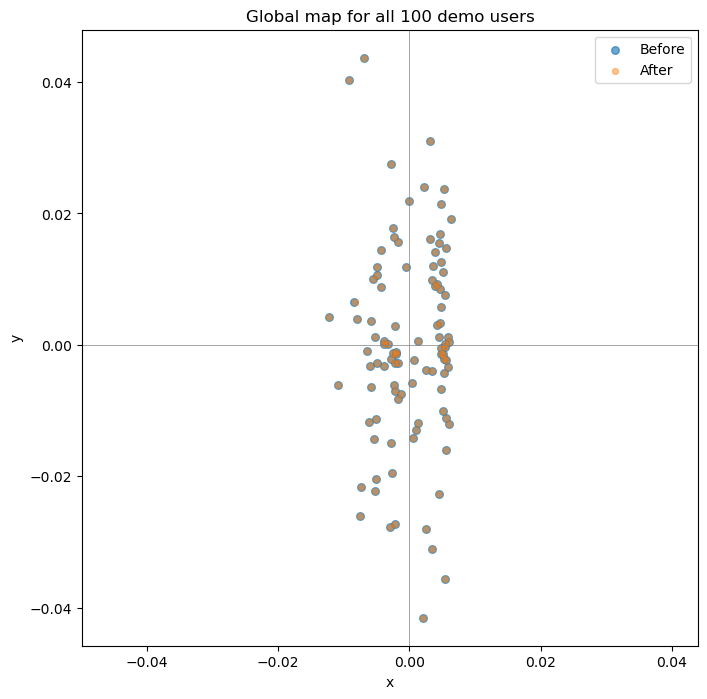

In [64]:
# Defensive loading so this cell can run even if prior cells were skipped.
if "global_before" not in globals() or "global_after" not in globals():
    global_before = load_csv("phase24_global_before.csv")
    global_after = load_csv("phase24_global_after.csv")

required_cols = {"x", "y", "nickname"}
missing_before = required_cols - set(global_before.columns)
missing_after = required_cols - set(global_after.columns)

if missing_before:
    raise ValueError(
        f"phase24_global_before.csv is missing columns: {sorted(missing_before)}. "
        "Regenerate artifacts with: cd backend && ./venv/bin/python scripts/run_phase24_demo_pipeline.py --use-fixture-data"
    )
if missing_after:
    raise ValueError(
        f"phase24_global_after.csv is missing columns: {sorted(missing_after)}. "
        "Regenerate artifacts with: cd backend && ./venv/bin/python scripts/run_phase24_demo_pipeline.py --use-fixture-data"
    )
if len(global_before) == 0 or len(global_after) == 0:
    raise ValueError(
        "Global demo CSVs are empty. Regenerate artifacts with: "
        "cd backend && ./venv/bin/python scripts/run_phase24_demo_pipeline.py --use-fixture-data"
    )

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(global_before["x"], global_before["y"], s=30, alpha=0.65, label="Before")
ax.scatter(global_after["x"], global_after["y"], s=18, alpha=0.45, label="After")
ax.set_title("Global map for all 100 demo users")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axhline(0.0, color="gray", lw=0.5)
ax.axvline(0.0, color="gray", lw=0.5)
ax.legend()
ax.set_aspect("equal")
ax.set_box_aspect(1)
plt.show()


## 2) Eleanor Colvin ego subset (20 friends)


In [65]:
ego_before = load_csv("phase24_eleanor_ego_before.csv")
ego_after = load_csv("phase24_eleanor_ego_after.csv")

print(f"Eleanor ego before rows: {len(ego_before)}")
print(f"Eleanor ego after rows: {len(ego_after)}")

Eleanor ego before rows: 21
Eleanor ego after rows: 21


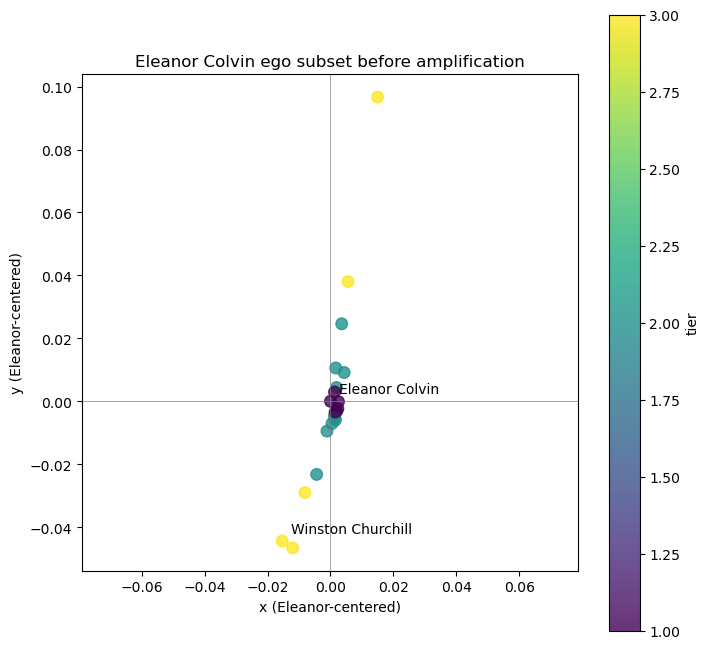

In [66]:
fig, ax = plt.subplots(figsize=(8, 8))
tiers = ego_before["tier"].astype(int)
scatter = ax.scatter(
    ego_before["x"], ego_before["y"], c=tiers, cmap="viridis", s=70, alpha=0.8
)

for _, row in ego_before.iterrows():
    if row["nickname"] in {"Eleanor Colvin", "Winston Churchill"}:
        ax.annotate(
            row["nickname"],
            (row["x"], row["y"]),
            xytext=(6, 6),
            textcoords="offset points",
        )

ax.set_title("Eleanor Colvin ego subset before amplification")
ax.set_xlabel("x (Eleanor-centered)")
ax.set_ylabel("y (Eleanor-centered)")
ax.axhline(0.0, color="gray", lw=0.5)
ax.axvline(0.0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.set_box_aspect(1)
fig.colorbar(scatter, ax=ax, label="tier")
plt.show()

## 3) Eleanor-centered coordinate shift


In [67]:
shift = load_csv("phase24_eleanor_shift.csv")

top_shift = shift.assign(
    distance=((shift["delta_x"] ** 2 + shift["delta_y"] ** 2) ** 0.5)
)
top_shift = top_shift.sort_values("distance", ascending=False).head(10)
top_shift[["nickname", "delta_x", "delta_y", "distance"]]

,nickname,delta_x,delta_y,distance
76,Winston Churchill,5.831574e-06,0.000013,0.000014
53,Jordan Anderson,2.267422e-06,0.000007,0.000007
91,Quinn Anderson,1.873368e-06,0.000005,0.000006
86,Reese Jordan,1.635439e-06,0.000004,0.000005
7,Taylor Bennett,-3.246676e-07,-0.000003,0.000003
25,Avery Bennett,-3.182002e-07,-0.000003,0.000003
69,Quinn Bennett,-3.097805e-07,-0.000003,0.000003
83,Riley Bennett,-3.395211e-07,-0.000003,0.000003
94,Hayden Bennett,-3.357788e-07,-0.000003,0.000003
80,Morgan Bennett,-3.247519e-07,-0.000003,0.000003


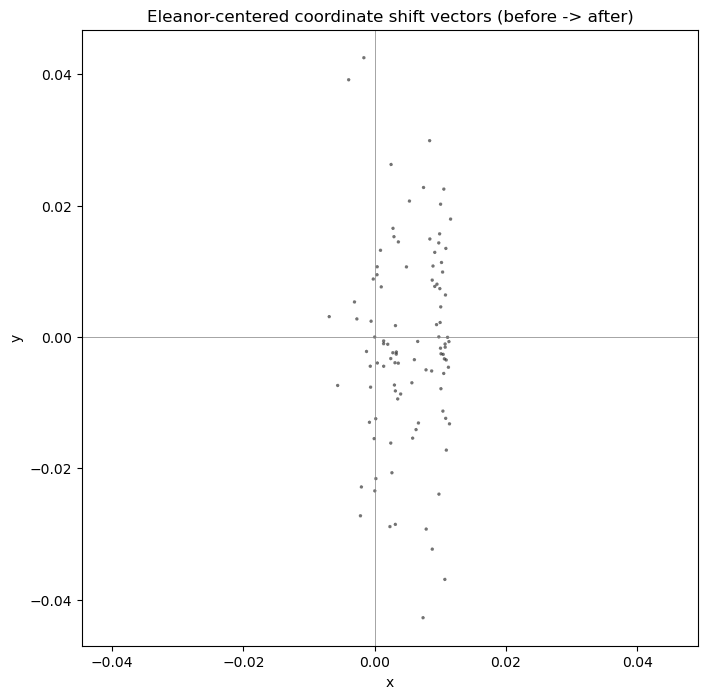

In [68]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.quiver(
    shift["before_x"],
    shift["before_y"],
    shift["delta_x"],
    shift["delta_y"],
    angles="xy",
    scale_units="xy",
    scale=1,
    alpha=0.55,
)
ax.set_title("Eleanor-centered coordinate shift vectors (before -> after)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axhline(0.0, color="gray", lw=0.5)
ax.axvline(0.0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.set_box_aspect(1)
plt.show()

## 4) Side-by-side before/after Eleanor map with boosted Eleanor<->Winston likes/comments


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


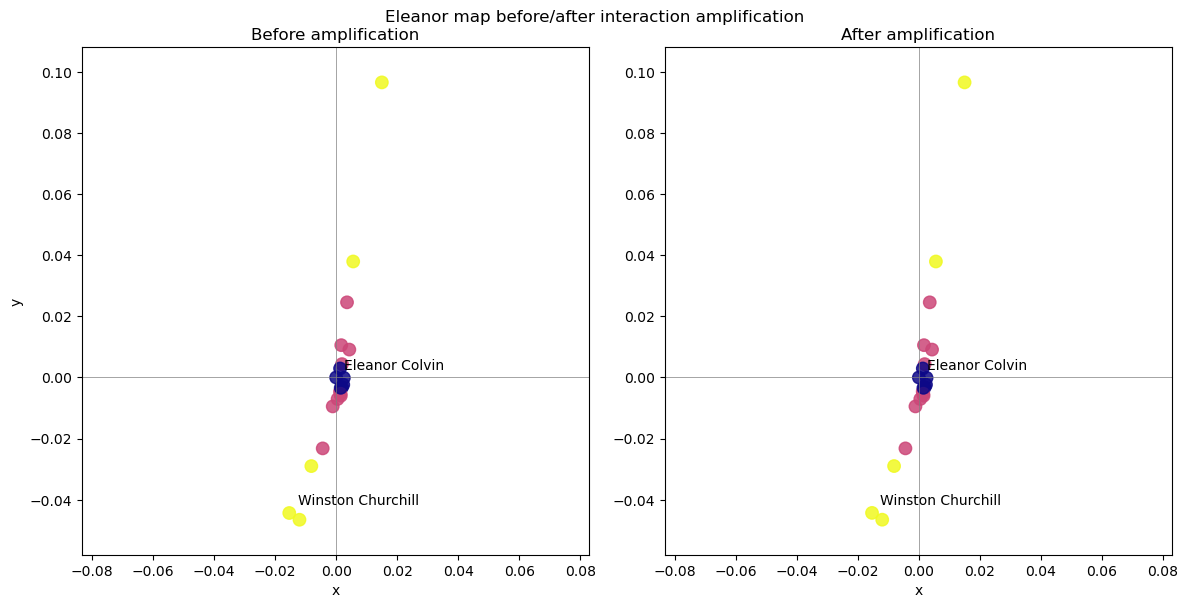

{'amplified': {'comments': 4011, 'dms': 5, 'likes': 5018},
 'baseline': {'comments': 11, 'dms': 5, 'likes': 18},
 'pair': {'user_id_a': 'aa834b27-6e25-52c6-86de-e105a0bfc2f1',
  'user_id_b': 'afec5144-e6a3-511f-9dc2-02f8ec57d8ac'}}

In [69]:
side_by_side = load_json("phase24_eleanor_side_by_side.json")
before_df = pd.DataFrame(side_by_side["before"])
after_df = pd.DataFrame(side_by_side["after"])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, frame, label in [
    (axes[0], before_df, "Before amplification"),
    (axes[1], after_df, "After amplification"),
]:
    ax.scatter(frame["x"], frame["y"], c=frame["tier"], cmap="plasma", s=80, alpha=0.85)
    for _, row in frame.iterrows():
        if row["nickname"] in {"Eleanor Colvin", "Winston Churchill"}:
            ax.annotate(
                row["nickname"],
                (row["x"], row["y"]),
                xytext=(6, 6),
                textcoords="offset points",
            )
    ax.set_title(label)
    ax.axhline(0.0, color="gray", lw=0.5)
    ax.axvline(0.0, color="gray", lw=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_box_aspect(1)


# keep both panels on the same coordinate window for fair visual comparison
combined_x = pd.concat([before_df["x"], after_df["x"]])
combined_y = pd.concat([before_df["y"], after_df["y"]])
pad_x = (combined_x.max() - combined_x.min()) * 0.08 if len(combined_x) else 0.1
pad_y = (combined_y.max() - combined_y.min()) * 0.08 if len(combined_y) else 0.1
x_min, x_max = combined_x.min() - pad_x, combined_x.max() + pad_x
y_min, y_max = combined_y.min() - pad_y, combined_y.max() + pad_y
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.suptitle("Eleanor map before/after interaction amplification")
axes[0].set_xlabel("x")
axes[1].set_xlabel("x")
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

side_by_side["comparison"]

## 5) Euclidean distance proof (Eleanor vs Winston)

This section computes the direct Euclidean distance between **Eleanor Colvin** and **Winston Churchill** in the Eleanor-centered ego map, before and after amplification. A shorter distance after amplification confirms the stronger interaction pulled Winston closer in embedding space.


Distance(Eleanor Colvin ↔ Winston Churchill) BEFORE: 0.046987
Distance(Eleanor Colvin ↔ Winston Churchill) AFTER : 0.046950
Change (after - before): -0.000037


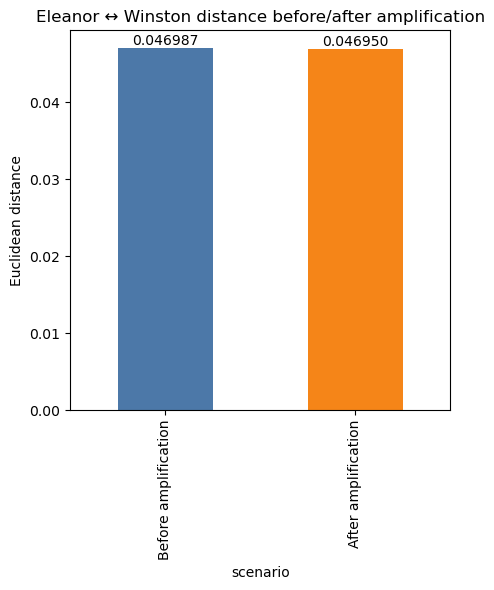

,scenario,euclidean_distance,delta_vs_before
0,Before amplification,0.046987,0.000000
1,After amplification,0.046950,-0.000037


In [70]:
pair = {"a": "Eleanor Colvin", "b": "Winston Churchill"}


def euclidean_between(df, a, b):
    row_a = df.loc[df["nickname"] == a, ["x", "y"]].iloc[0]
    row_b = df.loc[df["nickname"] == b, ["x", "y"]].iloc[0]
    dx = float(row_a["x"] - row_b["x"])
    dy = float(row_a["y"] - row_b["y"])
    return (dx**2 + dy**2) ** 0.5


d_before = euclidean_between(ego_before, pair["a"], pair["b"])
d_after = euclidean_between(ego_after, pair["a"], pair["b"])

comparison = pd.DataFrame(
    [
        {"scenario": "Before amplification", "euclidean_distance": d_before},
        {"scenario": "After amplification", "euclidean_distance": d_after},
    ]
)
comparison["delta_vs_before"] = comparison["euclidean_distance"] - d_before

print(f"Distance({pair['a']} ↔ {pair['b']}) BEFORE: {d_before:.6f}")
print(f"Distance({pair['a']} ↔ {pair['b']}) AFTER : {d_after:.6f}")
print(f"Change (after - before): {d_after - d_before:+.6f}")

ax = comparison.plot(
    kind="bar",
    x="scenario",
    y="euclidean_distance",
    legend=False,
    figsize=(6, 6),
    color=["#4c78a8", "#f58518"],
)
ax.set_ylabel("Euclidean distance")
ax.set_title("Eleanor ↔ Winston distance before/after amplification")
ax.set_box_aspect(1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.6f")
plt.tight_layout()
plt.show()

comparison


## 6) Distance trend across amplification levels

This section shows how **Eleanor ↔ Winston distance** changes as we increase interaction amplification.
For stakeholders: a lower value means the pair is closer in embedding space after stronger interaction signals.


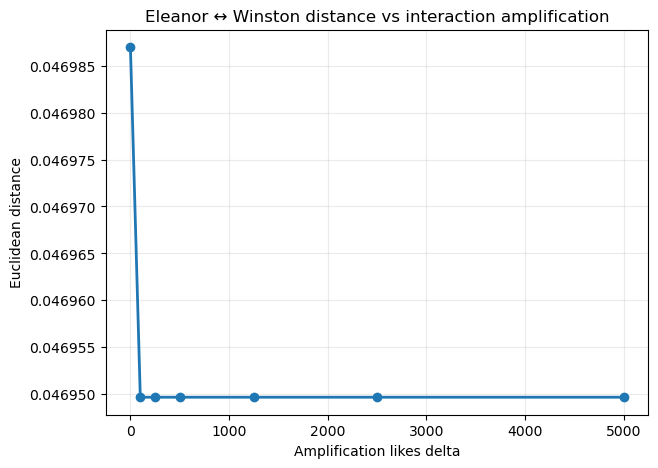

,amplification_likes,amplification_comments,euclidean_distance,distance_delta_from_baseline
0,0,0,0.046987,0.000000
1,100,80,0.046950,-0.000037
2,250,200,0.046950,-0.000037
3,500,400,0.046950,-0.000037
4,1250,1000,0.046950,-0.000037
5,2500,2000,0.046950,-0.000037
6,5000,4000,0.046950,-0.000037


In [71]:
distance_curve = load_csv("phase24_eleanor_winston_distance_curve.csv").sort_values("amplification_likes")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    distance_curve["amplification_likes"],
    distance_curve["euclidean_distance"],
    marker="o",
    linewidth=2,
)
ax.set_title("Eleanor ↔ Winston distance vs interaction amplification")
ax.set_xlabel("Amplification likes delta")
ax.set_ylabel("Euclidean distance")
ax.grid(True, alpha=0.25)
plt.show()

distance_curve[[
    "amplification_likes",
    "amplification_comments",
    "euclidean_distance",
    "distance_delta_from_baseline",
]].head(8)


## 7) Rank and force diagnostics across amplification levels

Phase 25 adds explainability fields that show *why* movement does or does not change:
- `nearest_neighbor_rank` and `rank_delta_from_baseline`
- `effective_pull` and `effective_pull_delta_from_baseline`
- `movement_explanation` narrative strings

For non-technical readers: rank tells us relative closeness ordering, while effective pull reflects the strength of attraction after sensitivity scaling and caps.


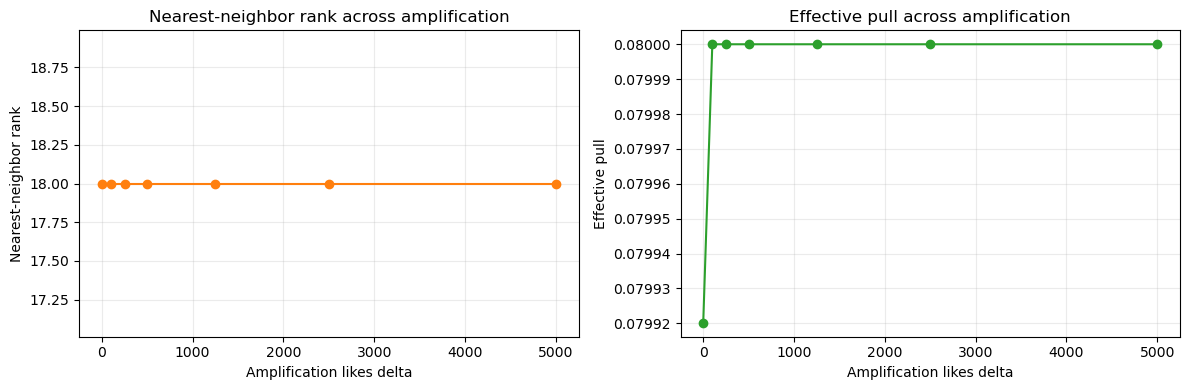

,amplification_likes,nearest_neighbor_rank,rank_delta_from_baseline,effective_pull,effective_pull_delta_from_baseline,movement_explanation
0,0,18,0,0.07992,0.00000,distance=stable; rank=unchanged; final_weight_...
1,100,18,0,0.08000,0.00008,distance=closer; rank=unchanged; final_weight_...
2,250,18,0,0.08000,0.00008,distance=closer; rank=unchanged; final_weight_...
3,500,18,0,0.08000,0.00008,distance=closer; rank=unchanged; final_weight_...
4,1250,18,0,0.08000,0.00008,distance=closer; rank=unchanged; final_weight_...
5,2500,18,0,0.08000,0.00008,distance=closer; rank=unchanged; final_weight_...
6,5000,18,0,0.08000,0.00008,distance=closer; rank=unchanged; final_weight_...


In [72]:
distance_curve = load_csv("phase24_eleanor_winston_distance_curve.csv").sort_values("amplification_likes")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    distance_curve["amplification_likes"],
    distance_curve["nearest_neighbor_rank"],
    marker="o",
    color="tab:orange",
)
axes[0].set_title("Nearest-neighbor rank across amplification")
axes[0].set_xlabel("Amplification likes delta")
axes[0].set_ylabel("Nearest-neighbor rank")
axes[0].grid(True, alpha=0.25)

axes[1].plot(
    distance_curve["amplification_likes"],
    distance_curve["effective_pull"],
    marker="o",
    color="tab:green",
)
axes[1].set_title("Effective pull across amplification")
axes[1].set_xlabel("Amplification likes delta")
axes[1].set_ylabel("Effective pull")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

distance_curve[[
    "amplification_likes",
    "nearest_neighbor_rank",
    "rank_delta_from_baseline",
    "effective_pull",
    "effective_pull_delta_from_baseline",
    "movement_explanation",
]]


## 8) Side-by-side mode comparison (6 plots: each mode before/after)

This section shows a 3x2 grid: one row per mode (`natural`, `strong-bounded`, `uncapped`) and columns for `before` vs `after`.
Eleanor and Winston are outlined in red so movement is easy to compare visually.


In [73]:
MODE_DIRS = {
    "natural": Path("data-mode-natural"),
    "strong-bounded": Path("data-mode-strong"),
    "uncapped": Path("data-mode-uncapped"),
}

def load_mode_curve(mode: str) -> pd.DataFrame:
    base = MODE_DIRS[mode]
    path = base / "phase24_eleanor_winston_distance_curve.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Generate with: cd backend && ./venv/bin/python scripts/run_phase24_demo_pipeline.py --use-fixture-data --sensitivity-mode {mode} --output-dir ../demo/{base}"
        )
    df = pd.read_csv(path).sort_values("amplification_likes").copy()
    df["mode"] = mode
    return df

mode_curves = {mode: load_mode_curve(mode) for mode in MODE_DIRS}

comparison = pd.concat(
    [
        mode_curves[mode][[
            "mode",
            "amplification_likes",
            "euclidean_distance",
            "nearest_neighbor_rank",
            "effective_pull",
            "final_weight",
        ]]
        for mode in MODE_DIRS
    ],
    ignore_index=True,
)

summary = comparison.groupby("mode", as_index=False).agg(
    baseline_distance=("euclidean_distance", "first"),
    final_distance=("euclidean_distance", "last"),
    baseline_rank=("nearest_neighbor_rank", "first"),
    final_rank=("nearest_neighbor_rank", "last"),
    baseline_pull=("effective_pull", "first"),
    final_pull=("effective_pull", "last"),
    final_weight=("final_weight", "last"),
)
summary["distance_delta"] = summary["final_distance"] - summary["baseline_distance"]
summary["rank_delta"] = summary["final_rank"] - summary["baseline_rank"]
summary["pull_delta"] = summary["final_pull"] - summary["baseline_pull"]
summary.sort_values("final_distance")


,mode,baseline_distance,final_distance,baseline_rank,final_rank,baseline_pull,final_pull,final_weight,distance_delta,rank_delta,pull_delta
2,uncapped,0.055448,0.015082,8,2,0.051043,0.1200,1.50,-0.040366,-6,0.068957
1,strong-bounded,0.081993,0.022976,5,1,0.034029,0.0792,0.99,-0.059017,-4,0.045171
0,natural,0.057813,0.057813,17,17,0.073600,0.0736,0.92,0.000000,0,0.000000


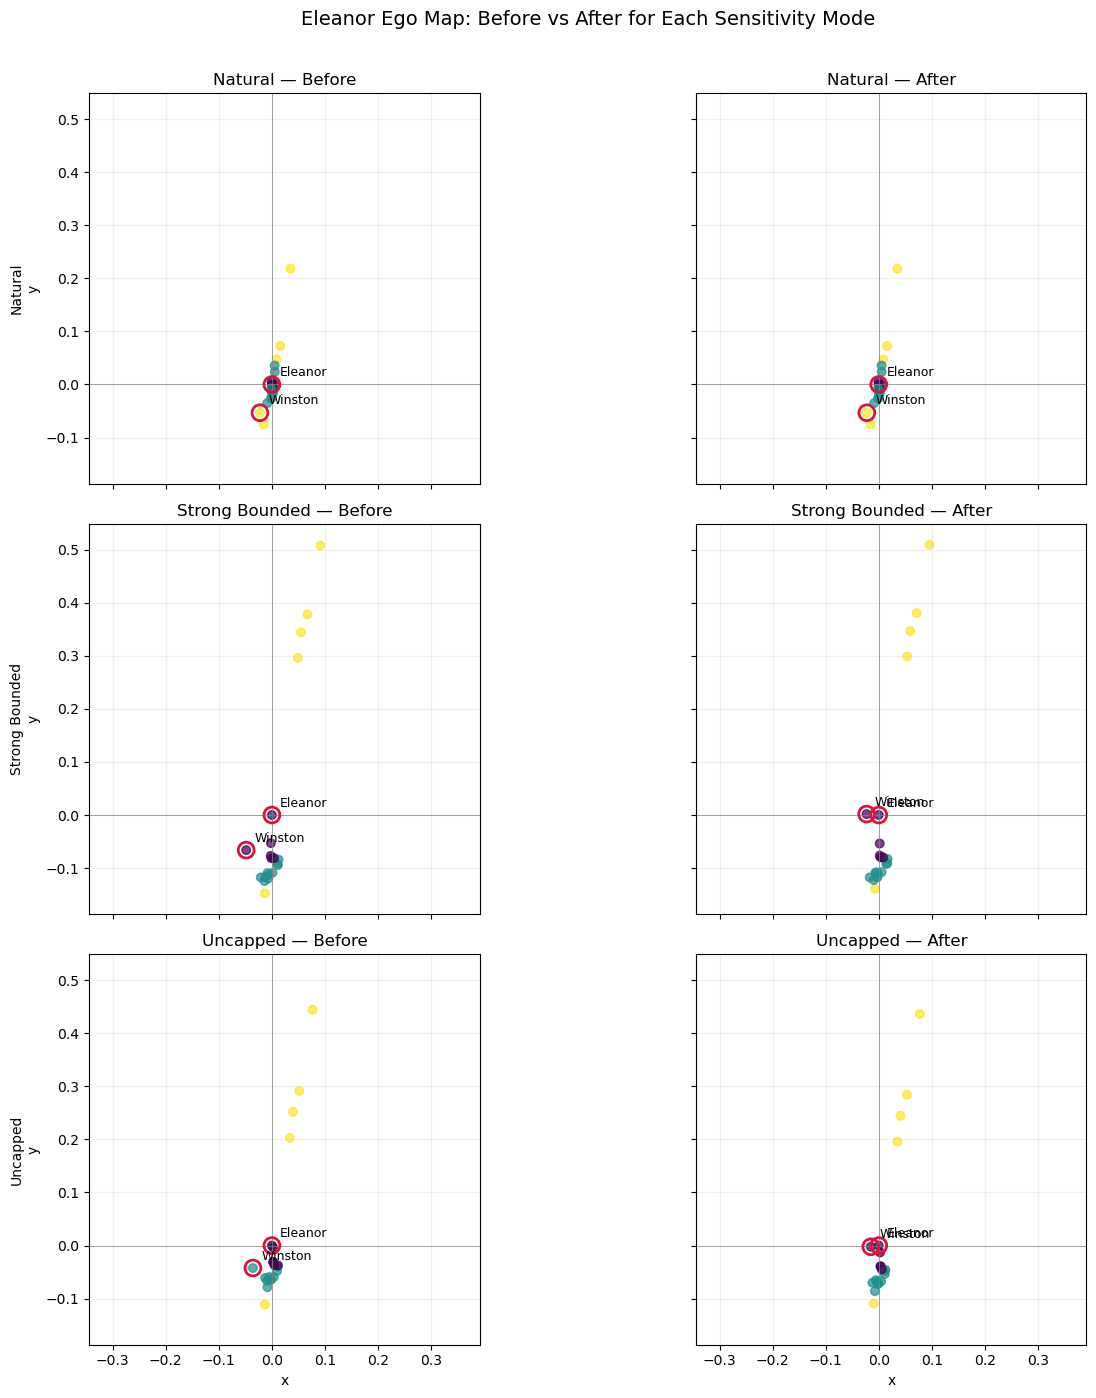

In [74]:
def load_mode_ego(mode: str, stage: str) -> pd.DataFrame:
    base = MODE_DIRS[mode]
    path = base / f"phase24_eleanor_ego_{stage}.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Generate with: cd backend && ./venv/bin/python scripts/run_phase24_demo_pipeline.py --use-fixture-data --sensitivity-mode {mode} --output-dir ../demo/{base}"
        )
    df = pd.read_csv(path).copy()
    required = {"x", "y", "nickname", "tier"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    return df

mode_ego = {
    mode: {
        "before": load_mode_ego(mode, "before"),
        "after": load_mode_ego(mode, "after"),
    }
    for mode in MODE_DIRS
}

all_frames = [mode_ego[m][s] for m in MODE_DIRS for s in ("before", "after")]
x_min = min(df["x"].min() for df in all_frames)
x_max = max(df["x"].max() for df in all_frames)
y_min = min(df["y"].min() for df in all_frames)
y_max = max(df["y"].max() for df in all_frames)
x_center = (x_min + x_max) / 2
y_center = (y_min + y_max) / 2
max_span = max(x_max - x_min, y_max - y_min, 1e-6)
half_span = (max_span * 0.56)

fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True, sharey=True)
mode_order = ["natural", "strong-bounded", "uncapped"]

for row_idx, mode in enumerate(mode_order):
    for col_idx, stage in enumerate(("before", "after")):
        ax = axes[row_idx, col_idx]
        df = mode_ego[mode][stage]
        tiers = df["tier"].astype(int)
        ax.scatter(df["x"], df["y"], c=tiers, cmap="viridis", s=38, alpha=0.72)

        focus = df[df["nickname"].isin(["Eleanor Colvin", "Winston Churchill"])]
        ax.scatter(
            focus["x"],
            focus["y"],
            s=130,
            facecolors="none",
            edgecolors="crimson",
            linewidths=2.0,
            zorder=3,
        )
        for _, frow in focus.iterrows():
            short = "Eleanor" if frow["nickname"] == "Eleanor Colvin" else "Winston"
            ax.annotate(short, (frow["x"], frow["y"]), xytext=(6, 6), textcoords="offset points", fontsize=9)

        ax.axhline(0.0, color="gray", lw=0.5)
        ax.axvline(0.0, color="gray", lw=0.5)
        ax.set_box_aspect(1)
        ax.set_xlim(x_center - half_span, x_center + half_span)
        ax.set_ylim(y_center - half_span, y_center + half_span)
        ax.grid(True, alpha=0.18)

        title_mode = mode.replace("-", " ").title()
        ax.set_title(f"{title_mode} — {stage.title()}")
        if col_idx == 0:
            ax.set_ylabel(f"{title_mode}\ny")
        if row_idx == len(mode_order) - 1:
            ax.set_xlabel("x")

fig.suptitle("Eleanor Ego Map: Before vs After for Each Sensitivity Mode", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


In [75]:
comparison.pivot(index="amplification_likes", columns="mode", values="euclidean_distance")


mode,natural,strong-bounded,uncapped
amplification_likes,,,
0,0.057813,0.081993,0.055448
24,0.057813,NaN,NaN
60,0.057813,NaN,NaN
100,NaN,0.022976,0.015083
120,0.057813,NaN,NaN
250,NaN,0.022976,0.015082
300,0.057813,NaN,NaN
500,NaN,0.022976,0.015082
600,0.057813,NaN,NaN


## 9) Safeguards and interpretation notes for non-technical review

- **Guardrail remains on:** movement clipping is still enabled, even in the demo-strong preset.
- **How to read stable rows:** if rank and distance remain flat while effective pull rises, other neighborhood constraints can dominate.
- **Operational guidance:** always compare production-safe default first, then demo-strong sensitivity, and explain changes using distance + rank + force together.
